In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [2]:
#load imdb dataset
(x_train, y_train),(x_test,y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

#Pad sequences
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=100)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=100)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Building RNN Model
model_rnn = models.Sequential([
    layers.Embedding(10000, 32, input_length=100),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_rnn = model_rnn.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6998 - loss: 0.5466 - val_accuracy: 0.8046 - val_loss: 0.4276
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8727 - loss: 0.3149 - val_accuracy: 0.8010 - val_loss: 0.4272
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9301 - loss: 0.1874 - val_accuracy: 0.8238 - val_loss: 0.4539
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9737 - loss: 0.0831 - val_accuracy: 0.8150 - val_loss: 0.5789
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9852 - loss: 0.0465 - val_accuracy: 0.7796 - val_loss: 0.7060


In [4]:
#LSTM Model
model_lstm = models.Sequential([
    layers.Embedding(10000,32,input_length=100),
    layers.LSTM(32),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_lstm = model_lstm.fit(x_train, y_train,epochs=5,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.7809 - loss: 0.4493 - val_accuracy: 0.8476 - val_loss: 0.3514
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.8950 - loss: 0.2630 - val_accuracy: 0.8440 - val_loss: 0.3672
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.9283 - loss: 0.1907 - val_accuracy: 0.8412 - val_loss: 0.4129
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9506 - loss: 0.1378 - val_accuracy: 0.8392 - val_loss: 0.4422
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9647 - loss: 0.1045 - val_accuracy: 0.8344 - val_loss: 0.5478


In [5]:
#GRU Model
model_gru = models.Sequential([
    layers.Embedding(10000, 32, input_length=100),
    layers.GRU(32),
    layers.Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_gru = model_gru.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.7773 - loss: 0.4518 - val_accuracy: 0.8424 - val_loss: 0.3606
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.8855 - loss: 0.2827 - val_accuracy: 0.8446 - val_loss: 0.3539
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9189 - loss: 0.2187 - val_accuracy: 0.8380 - val_loss: 0.3842
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9423 - loss: 0.1630 - val_accuracy: 0.8402 - val_loss: 0.4210
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9567 - loss: 0.1227 - val_accuracy: 0.8324 - val_loss: 0.4990


In [6]:
print("RNN:", history_rnn.history['val_accuracy'][-1])
print("LSTM:", history_lstm.history['val_accuracy'][-1])
print("GRU:", history_gru.history['val_accuracy'][-1])

RNN: 0.7796000242233276
LSTM: 0.8343999981880188
GRU: 0.8324000239372253


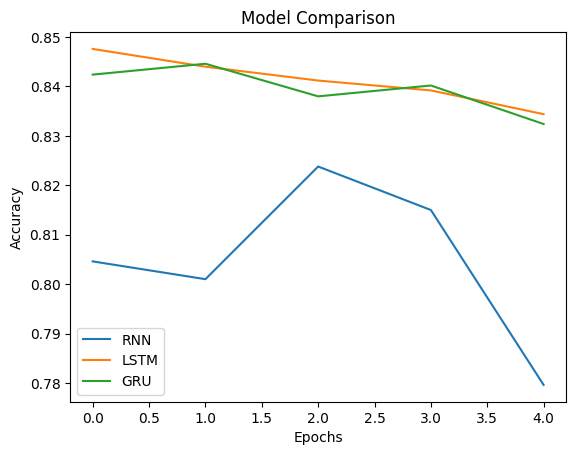

In [7]:
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()